# Urdu Hate Speech Detection — Assignment 3
## **Name**: **Hania** **Khan**
## **Roll** **Number**: **BS**-**23**-**IB**-**103973**

**Models implemented:**
- Binary Naive Bayes (BernoulliNB)
- Multinomial Naive Bayes
- Logistic Regression (Binary & Multi-class)
- RNN
- LSTM
- GRU

## 1. Install & Import Dependencies

In [ ]:
#Name: Hania Khan
#Roll Number: BS-23-IB-103973
import subprocess, sys

pkgs = [
    'numpy==1.26.4',
    'pandas',
    'scikit-learn',
    'imbalanced-learn',
    'matplotlib',
    'seaborn',
    'tensorflow',
]

for pkg in pkgs:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           '--force-reinstall' if 'numpy' in pkg else '--upgrade',
                           pkg])
    print(f'  installed {pkg}')

print('\nAll packages installed. Restarting runtime now')

import os
os.kill(os.getpid(), 9)

  installed numpy==1.26.4
  installed pandas
  installed scikit-learn
  installed imbalanced-learn
  installed matplotlib
  installed seaborn


In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, classification_report,
                              confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

#DeepLearning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM, GRU,
                                      Dense, Dropout, Bidirectional)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

#Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.21.0
GPU available: True


## 2. Load Dataset

In [2]:
#Upload Dataset
from google.colab import files
uploaded = files.upload()

Saving Urdu_combined.csv to Urdu_combined.csv


In [3]:
df = pd.read_csv('Urdu_combined.csv')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Shape: (16342, 2)
Columns: ['Comments', 'Label']


,Comments,Label
0,یہ عمر گانڈوں کی گانڈ مار کر گیا,offensive
1,انسان بن بغیرت نہ بن,offensive
2,تو خد بغیرت ھے,offensive
3,اقرار الحسن زندہ آباد پھونکوں والی سرکار اگر ت...,offensive
4,یہ بھی سوچنے کی بات ہے کہ کتنے بغیرت اور ان پڑ...,offensive


Cleaned shape: (16337, 2)

Label distribution:
label
normal       7891
offensive    6199
hate         2247
Name: count, dtype: int64


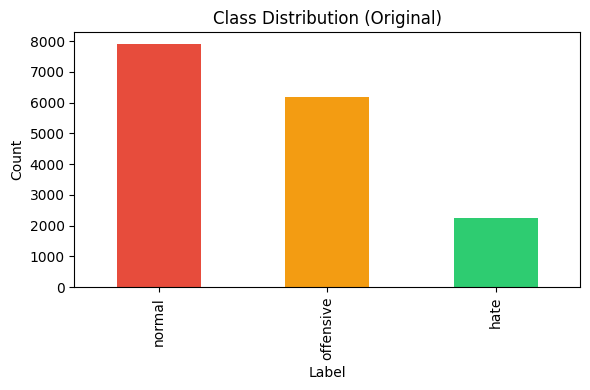

In [4]:
df.columns = ['text', 'label']

# Drop noisy / extremely rare label artifacts (single characters 'n', 'm')
valid_labels = ['hate', 'offensive', 'normal']
df = df[df['label'].isin(valid_labels)].copy()
df.reset_index(drop=True, inplace=True)

print('Cleaned shape:', df.shape)
print()
print('Label distribution:')
print(df['label'].value_counts())

# Visualise
fig, ax = plt.subplots(figsize=(6, 4))
df['label'].value_counts().plot(kind='bar', ax=ax, color=['#e74c3c','#f39c12','#2ecc71'])
ax.set_title('Class Distribution (Original)')
ax.set_ylabel('Count')
ax.set_xlabel('Label')
plt.tight_layout()
plt.show()

## 3. Preprocessing
Following the paper's pipeline:
- Remove URLs, emojis, HTML tags, punctuation, extra spaces
- Remove usernames / @mentions
- Remove Roman Urdu, English, and Arabic words (keep only Urdu script)
- Urdu-specific normalization
- Tokenization

In [5]:
# Unicode ranges
#Urdu / Nastaliq  : \u0600-\u06FF  (includes Arabic)
#and REMOVE pure Latin (English / Roman Urdu)
EMOJI_RE = re.compile(
    "["
    u"\U0001F600-\U0001F64F"
    u"\U0001F300-\U0001F5FF"
    u"\U0001F680-\U0001F6FF"
    u"\U0001F1E0-\U0001F1FF"
    u"\U00002702-\U000027B0"
    u"\U000024C2-\U0001F251"
    "]+", flags=re.UNICODE
)


URDU_RE = re.compile(r'[^\u0600-\u06FF\u0750-\u077F\uFB50-\uFDFF\uFE70-\uFEFF\s]')

ARABIC_ONLY_RE = re.compile(r'[\u0629\u0671\u0622\u0623\u0625\u0627\u0649]')

NORM_MAP = str.maketrans({
    '\u0622': '\u0627',
    '\u0623': '\u0627',
    '\u0625': '\u0627',
    '\u0649': '\u06CC',
    '\u06C1': '\u06BE',
    '\u0643': '\u06A9',
    '\u0629': '\u06C3',
})


def preprocess_urdu(text: str) -> str:
    """Full preprocessing pipeline for Urdu text."""
    if not isinstance(text, str):
        return ''

    text = text.lower()

    #Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    #Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)

    #Remove @usernames and #hashtags
    text = re.sub(r'[@#]\w+', ' ', text)

    #Remove emojis
    text = EMOJI_RE.sub(' ', text)

    #Remove numbers
    text = re.sub(r'\d+', ' ', text)

    #Urdu normalization
    text = text.translate(NORM_MAP)

    #Keep only Urdu script characters + whitespace
    text = URDU_RE.sub(' ', text)

    #Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply preprocessing
df['clean_text'] = df['text'].apply(preprocess_urdu)

df = df[df['clean_text'].str.strip() != ''].copy()
df.reset_index(drop=True, inplace=True)

print('Shape after preprocessing:', df.shape)
print()
print('Sample cleaned texts:')
for i in range(3):
    print(f'  Original : {df["text"].iloc[i]}')
    print(f'  Cleaned  : {df["clean_text"].iloc[i]}')
    print()

Shape after preprocessing: (16335, 3)

Sample cleaned texts:
  Original : یہ عمر گانڈوں کی گانڈ مار کر گیا
  Cleaned  : یھ عمر گانڈوں کی گانڈ مار کر گیا

  Original : انسان بن بغیرت نہ بن
  Cleaned  : انسان بن بغیرت نھ بن

  Original : تو خد بغیرت ھے
  Cleaned  : تو خد بغیرت ھے



## 4. Label Encoding
- **Binary classifiers** (Binary NB, LR-Binary): `hate + offensive → hate`, `normal → not_hate`
- **Multi-class classifiers** (Multinomial NB, LR-Multi, RNN, LSTM, GRU): `hate / offensive / normal` (3 classes)

In [6]:
#Binary labels
df['binary_label'] = df['label'].apply(lambda x: 'hate' if x in ['hate', 'offensive'] else 'not_hate')

#Multi-class labels
le = LabelEncoder()
df['multi_label'] = le.fit_transform(df['label'])   # hate=0, normal=1, offensive=2
NUM_CLASSES = len(le.classes_)

print('Binary label distribution:')
print(df['binary_label'].value_counts())
print()
print('Multi-class label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))
print(df['label'].value_counts())

Binary label distribution:
binary_label
hate        8445
not_hate    7890
Name: count, dtype: int64

Multi-class label mapping: {'hate': 0, 'normal': 1, 'offensive': 2}
label
normal       7890
offensive    6198
hate         2247
Name: count, dtype: int64


In [7]:
# Save processed dataset to CSV and download it
df.to_csv('Urdu_processed.csv', index=False)

from google.colab import files
files.download('Urdu_processed.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 5. Train / Validation / Test Split  
80% training | 10% validation | 10% test  (fixed seed = 42)

In [ ]:
df = df.copy()

In [ ]:
import pandas as pd

texts         = np.array(df['clean_text'].tolist(),    dtype=object)
binary_labels = np.array(df['binary_label'].tolist(),  dtype=object)
multi_labels  = np.array(df['multi_label'].tolist(),   dtype=np.int64)

texts         = texts.astype(str)
binary_labels = binary_labels.astype(str)

print('texts dtype      :', texts.dtype,         '| sample:', texts[0])
print('binary_labels    :', binary_labels.dtype,  '| sample:', binary_labels[0])
print('multi_labels     :', multi_labels.dtype,   '| sample:', multi_labels[0])

X_train, X_temp, y_bin_train, y_bin_temp, y_multi_train, y_multi_temp = train_test_split(
    texts, binary_labels, multi_labels,
    test_size=0.20, random_state=SEED, stratify=multi_labels
)

X_val, X_test, y_bin_val, y_bin_test, y_multi_val, y_multi_test = train_test_split(
    X_temp, y_bin_temp, y_multi_temp,
    test_size=0.50, random_state=SEED, stratify=y_multi_temp
)

print(f'\nTrain size : {len(X_train)}')
print(f'Val size   : {len(X_val)}')
print(f'Test size  : {len(X_test)}')

texts dtype      : <U2495 | sample: یھ عمر گانڈوں کی گانڈ مار کر گیا
binary_labels    : <U8 | sample: hate
multi_labels     : int64 | sample: 2

Train size : 13068
Val size   : 1633
Test size  : 1634


## 6. Feature Engineering — TF-IDF (for ML models)

In [ ]:
from scipy.sparse import hstack

tfidf_word = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 3),
    sublinear_tf=True,
    min_df=2,
    analyzer='word'
)

tfidf_char = TfidfVectorizer(
    max_features=20000,
    ngram_range=(2, 5),
    sublinear_tf=True,
    min_df=2,
    analyzer='char_wb'
)

X_train_w = tfidf_word.fit_transform(X_train)
X_val_w   = tfidf_word.transform(X_val)
X_test_w  = tfidf_word.transform(X_test)

X_train_c = tfidf_char.fit_transform(X_train)
X_val_c   = tfidf_char.transform(X_val)
X_test_c  = tfidf_char.transform(X_test)

X_train_tfidf = hstack([X_train_w, X_train_c])
X_val_tfidf   = hstack([X_val_w,   X_val_c])
X_test_tfidf  = hstack([X_test_w,  X_test_c])

print('Combined TF-IDF matrix shape (train):', X_train_tfidf.shape)

Combined TF-IDF matrix shape (train): (13068, 50000)


## 7. Helper: Evaluation Function

In [ ]:
results_log = {}
def evaluate_model(model_name, y_true, y_pred, labels=None, target_names=None):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f'\n========== {model_name} ==========')
    print(f'  Accuracy  : {acc*100:.2f}%')
    print(f'  Precision : {prec*100:.2f}%')
    print(f'  Recall    : {rec*100:.2f}%')
    print(f'  F1-Score  : {f1*100:.2f}%')
    print()
    print(classification_report(y_true, y_pred,
                                 target_names=target_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f'{model_name} — Confusion Matrix')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    results_log[model_name] = {
        'Accuracy':  round(acc*100, 2),
        'Precision': round(prec*100, 2),
        'Recall':    round(rec*100, 2),
        'F1-Score':  round(f1*100, 2)
    }
    return acc, f1

## 8. Model 1 — Binary Naive Bayes (BernoulliNB)


========== Binary Naive Bayes ==========
  Accuracy  : 78.58%
  Precision : 78.58%
  Recall    : 78.58%
  F1-Score  : 78.57%

              precision    recall  f1-score   support

        hate       0.79      0.81      0.80       845
    not_hate       0.79      0.76      0.78       789

    accuracy                           0.79      1634
   macro avg       0.79      0.79      0.79      1634
weighted avg       0.79      0.79      0.79      1634



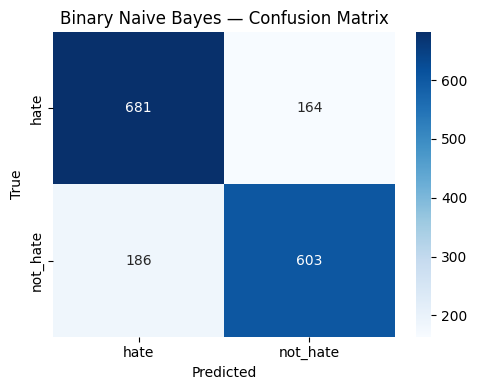

(0.7858017135862914, 0.7856637323846849)

In [ ]:
from sklearn.naive_bayes import BernoulliNB, ComplementNB
from sklearn.preprocessing import MaxAbsScaler

from scipy.sparse import hstack as sp_hstack

tfidf_bin_word = TfidfVectorizer(
    max_features=40000, ngram_range=(1, 3),
    sublinear_tf=True, binary=True, min_df=2, analyzer='word'
)
tfidf_bin_char = TfidfVectorizer(
    max_features=20000, ngram_range=(2, 5),
    sublinear_tf=True, binary=True, min_df=2, analyzer='char_wb'
)

X_tr_w = tfidf_bin_word.fit_transform(X_train)
X_te_w = tfidf_bin_word.transform(X_test)
X_tr_c = tfidf_bin_char.fit_transform(X_train)
X_te_c = tfidf_bin_char.transform(X_test)

X_tr_bin_feat = sp_hstack([X_tr_w, X_tr_c])
X_te_bin_feat = sp_hstack([X_te_w, X_te_c])

smote_bin = SMOTE(random_state=SEED, k_neighbors=5)
X_tr_bin_sm, y_bin_tr_sm = smote_bin.fit_resample(X_tr_bin_feat, y_bin_train)

cnb = ComplementNB(alpha=0.3, norm=True)
cnb.fit(X_tr_bin_sm, y_bin_tr_sm)
y_pred_bnb = cnb.predict(X_te_bin_feat)

evaluate_model('Binary Naive Bayes',
               y_bin_test, y_pred_bnb,
               labels=['hate', 'not_hate'],
               target_names=['hate', 'not_hate'])


## 9. Model 2 — Multinomial Naive Bayes (3-class)


========== Multinomial Naive Bayes ==========
  Accuracy  : 64.75%
  Precision : 66.62%
  Recall    : 64.75%
  F1-Score  : 65.41%

              precision    recall  f1-score   support

        hate       0.41      0.49      0.45       225
      normal       0.80      0.70      0.75       789
   offensive       0.58      0.64      0.61       620

    accuracy                           0.65      1634
   macro avg       0.60      0.61      0.60      1634
weighted avg       0.67      0.65      0.65      1634



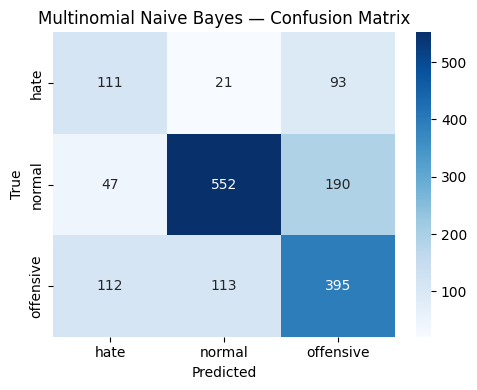

(0.6474908200734394, 0.6541036110540083)

In [ ]:
smote_multi = SMOTE(random_state=SEED, k_neighbors=3)
X_train_multi_sm, y_multi_train_sm = smote_multi.fit_resample(X_train_tfidf, y_multi_train)

mnb = MultinomialNB(alpha=0.05)
mnb.fit(X_train_multi_sm, y_multi_train_sm)
y_pred_mnb = mnb.predict(X_test_tfidf)

evaluate_model('Multinomial Naive Bayes',
               y_multi_test, y_pred_mnb,
               labels=[0, 1, 2],
               target_names=le.classes_)

## 10. Model 3 — Logistic Regression (Binary)


========== Logistic Regression (Binary) ==========
  Accuracy  : 80.54%
  Precision : 80.58%
  Recall    : 80.54%
  F1-Score  : 80.54%

              precision    recall  f1-score   support

        hate       0.82      0.80      0.81       845
    not_hate       0.79      0.81      0.80       789

    accuracy                           0.81      1634
   macro avg       0.81      0.81      0.81      1634
weighted avg       0.81      0.81      0.81      1634



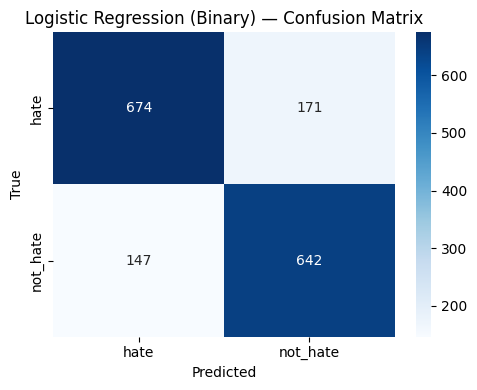

(0.8053855569155447, 0.8054415583019753)

In [ ]:
lr_bin = LogisticRegression(
    C=10.0,
    max_iter=2000,
    solver='saga',
    penalty='l2',
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)
lr_bin.fit(X_train_tfidf, y_bin_train)
y_pred_lr_bin = lr_bin.predict(X_test_tfidf)

evaluate_model('Logistic Regression (Binary)',
               y_bin_test, y_pred_lr_bin,
               labels=['hate', 'not_hate'],
               target_names=['hate', 'not_hate'])

## 11. Model 4 — Logistic Regression (Multi-class, 3 classes)


========== Logistic Regression (Multi-class) ==========
  Accuracy  : 69.95%
  Precision : 69.77%
  Recall    : 69.95%
  F1-Score  : 69.79%

              precision    recall  f1-score   support

        hate       0.50      0.52      0.51       225
      normal       0.78      0.82      0.80       789
   offensive       0.66      0.61      0.64       620

    accuracy                           0.70      1634
   macro avg       0.65      0.65      0.65      1634
weighted avg       0.70      0.70      0.70      1634



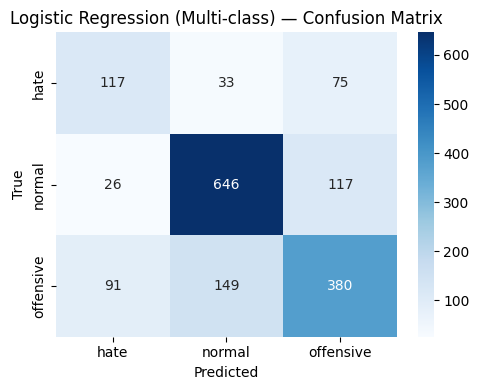

(0.6995104039167687, 0.6979358572622298)

In [ ]:
lr_multi = LogisticRegression(
    C=10.0,
    max_iter=2000,
    solver='saga',
    penalty='l2',
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)
lr_multi.fit(X_train_tfidf, y_multi_train)
y_pred_lr_multi = lr_multi.predict(X_test_tfidf)

evaluate_model('Logistic Regression (Multi-class)',
               y_multi_test, y_pred_lr_multi,
               labels=[0, 1, 2],
               target_names=le.classes_)

## 12. Feature Engineering — Tokenization + Padding (for DL models)

In [ ]:
VOCAB_SIZE  = 30000
MAX_LEN     = 128
EMBED_DIM   = 128

tokenizer_dl = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer_dl.fit_on_texts(X_train)

def encode_pad(texts):
    seqs = tokenizer_dl.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

X_train_dl = encode_pad(X_train)
X_val_dl   = encode_pad(X_val)
X_test_dl  = encode_pad(X_test)

y_train_cat = to_categorical(y_multi_train, num_classes=NUM_CLASSES)
y_val_cat   = to_categorical(y_multi_val,   num_classes=NUM_CLASSES)
y_test_cat  = to_categorical(y_multi_test,  num_classes=NUM_CLASSES)

cw_multi = compute_class_weight('balanced',
                                 classes=np.unique(y_multi_train),
                                 y=y_multi_train)
cw_multi_dict = dict(enumerate(cw_multi))
print('Class weights:', cw_multi_dict)
print('X_train_dl shape:', X_train_dl.shape)
print('Vocabulary size :', len(tokenizer_dl.word_index))

Class weights: {0: 2.4226918798665182, 1: 0.6901140684410646, 2: 0.8785800726099233}
X_train_dl shape: (13068, 128)
Vocabulary size : 21028


## 13. Common DL Training Callbacks

In [ ]:
def get_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=3,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=2, min_lr=1e-6, verbose=1)
    ]


def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['accuracy'],     label='Train Acc')
    axes[0].plot(history.history['val_accuracy'], label='Val Acc')
    axes[0].set_title(f'{model_name} — Accuracy')
    axes[0].legend()
    axes[1].plot(history.history['loss'],     label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title(f'{model_name} — Loss')
    axes[1].legend()
    plt.tight_layout()
    plt.show()


def evaluate_dl_model(model_name, model, X_test_in, y_test_int):
    y_prob = model.predict(X_test_in, batch_size=64, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    evaluate_model(model_name, y_test_int, y_pred,
                   labels=list(range(NUM_CLASSES)),
                   target_names=le.classes_)

## 14. Model 5 — RNN (SimpleRNN)

Model: "RNN_improved"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 128, 128)  │  3,840,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 128, 128)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 128)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 128, 512)  │    197,120 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 512)  │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 128, 256)  │    164,096 │ dropout[0][0],    │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128, 256)  │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ dropout_1[0][0],  │
│ (GlobalAveragePool… │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ dropout_1[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 512)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     65,664 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │        387 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,267,267 (16.28 MB)

 Trainable params: 4,267,267 (16.28 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
409/409 ━━━━━━━━━━━━━━━━━━━━ 46s 80ms/step - accuracy: 0.4805 - loss: 1.0247 - val_accuracy: 0.5499 - val_loss: 0.8986 - learning_rate: 3.0000e-04
Epoch 2/25
409/409 ━━━━━━━━━━━━━━━━━━━━ 23s 56ms/step - accuracy: 0.6029 - loss: 0.8530 - val_accuracy: 0.6069 - val_loss: 0.8508 - learning_rate: 3.0000e-04
Epoch 3/25
409/409 ━━━━━━━━━━━━━━━━━━━━ 40s 52ms/step - accuracy: 0.7051 - loss: 0.7237 - val_accuracy: 0.6209 - val_loss: 0.9018 - learning_rate: 3.0000e-04
Epoch 4/25
408/409 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7494 - loss: 0.6506
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
409/409 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.7661 - loss: 0.6284 - val_accuracy: 0.6081 - val_loss: 0.9640 - learning_rate: 3.0000e-04
Epoch 5/25
409/409 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.8352 - loss: 0.5061 - val_accuracy: 0.6142 - val_loss: 0.9366 - learning_rate: 1.5000e-04
Epoch 5: early stopping
Restoring model weights from the e

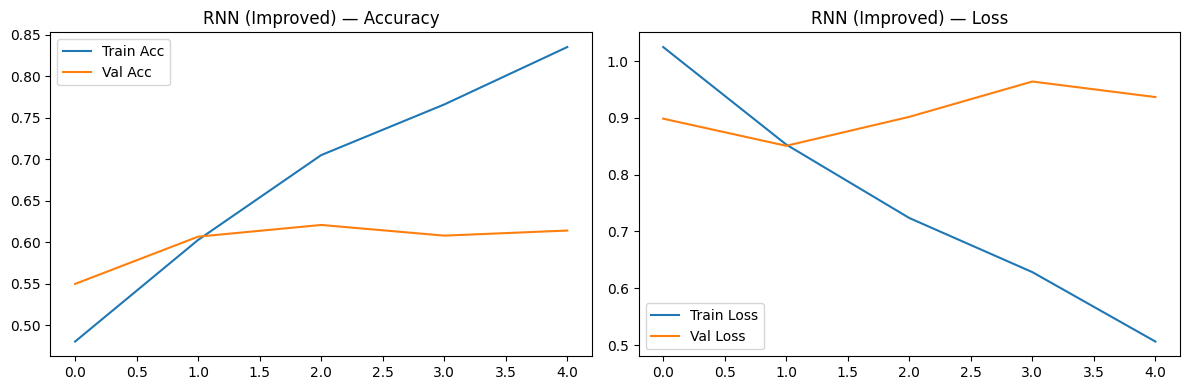


========== RNN ==========
  Accuracy  : 60.47%
  Precision : 62.31%
  Recall    : 60.47%
  F1-Score  : 59.48%

              precision    recall  f1-score   support

        hate       0.35      0.63      0.45       225
      normal       0.73      0.80      0.76       789
   offensive       0.59      0.34      0.43       620

    accuracy                           0.60      1634
   macro avg       0.56      0.59      0.55      1634
weighted avg       0.62      0.60      0.59      1634



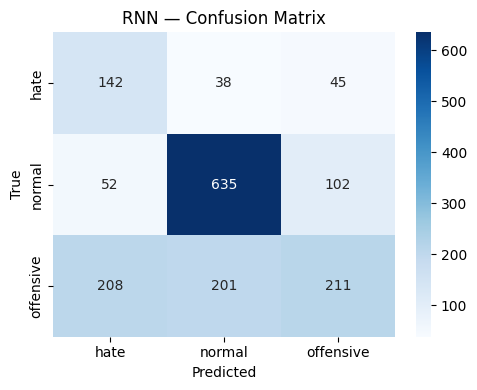

In [ ]:
tf.random.set_seed(SEED)

from tensorflow.keras.layers import (SpatialDropout1D, GlobalAveragePooling1D,
                                      GlobalMaxPooling1D, Concatenate, Input, Add)
from tensorflow.keras.models import Model

inputs = tf.keras.Input(shape=(MAX_LEN,))
x = tf.keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM,
                               input_length=MAX_LEN, mask_zero=True)(inputs)
x = SpatialDropout1D(0.3)(x)

x = tf.keras.layers.Bidirectional(
        SimpleRNN(256, return_sequences=True, activation='tanh'))(x)
x = Dropout(0.25)(x)

x = tf.keras.layers.Bidirectional(
        SimpleRNN(128, return_sequences=True, activation='tanh'))(x)
x = Dropout(0.25)(x)

avg_pool = GlobalAveragePooling1D()(x)
max_pool = GlobalMaxPooling1D()(x)
x = tf.keras.layers.Concatenate()([avg_pool, max_pool])

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

rnn_model = Model(inputs, outputs, name='RNN_improved')

rnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003, clipnorm=1.0),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

rnn_model.summary()

rnn_history = rnn_model.fit(
    X_train_dl, y_train_cat,
    validation_data=(X_val_dl, y_val_cat),
    epochs=25,
    batch_size=32,
    class_weight=cw_multi_dict,
    callbacks=get_callbacks(),
    verbose=1
)

plot_history(rnn_history, 'RNN (Improved)')
evaluate_dl_model('RNN', rnn_model, X_test_dl, y_multi_test)


## 15. Model 6 — LSTM

Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
409/409 ━━━━━━━━━━━━━━━━━━━━ 793s 2s/step - accuracy: 0.5627 - loss: 0.8910 - val_accuracy: 0.6767 - val_loss: 0.7750 - learning_rate: 0.0010
Epoch 2/20
409/409 ━━━━━━━━━━━━━━━━━━━━ 851s 2s/step - accuracy: 0.7401 - loss: 0.6119 - val_accuracy: 0.6761 - val_loss: 0.8238 - learning_rate: 0.0010
Epoch 3/20
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8288 - loss: 0.4340
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
409/409 ━━━━━━━━━━━━━━━━━━━━ 765s 2s/step - accuracy: 0.8450 - loss: 0.3982 - val_accuracy: 0.6448 - val_loss: 1.0172 - learning_rate: 0.0010
Epoch 4/20
409/409 ━━━━━━━━━━━━━━━━━━━━ 722s 2s/step - accuracy: 0.9092 - loss: 0.2506 - val_accuracy: 0.6473 - val_loss: 1.1628 - learning_rate: 5.0000e-04
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


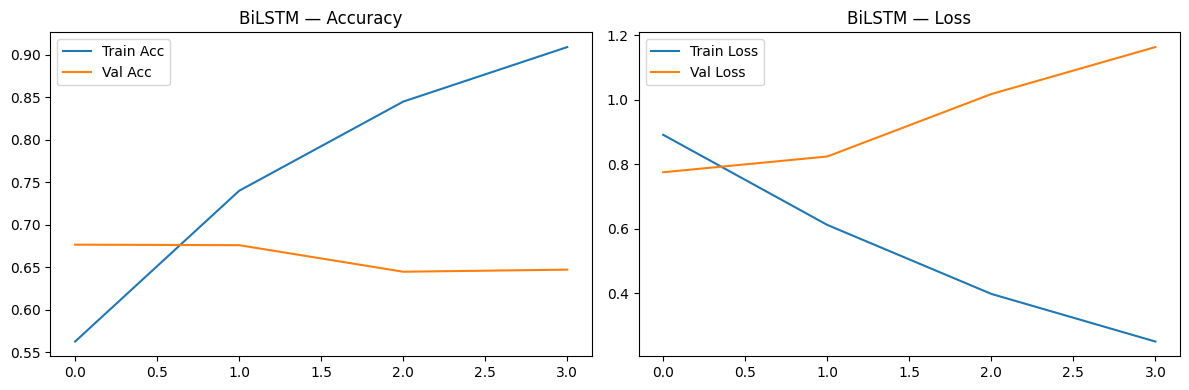


========== BiLSTM ==========
  Accuracy  : 65.91%
  Precision : 67.33%
  Recall    : 65.91%
  F1-Score  : 66.04%

              precision    recall  f1-score   support

        hate       0.43      0.65      0.52       225
      normal       0.77      0.78      0.78       789
   offensive       0.64      0.51      0.57       620

    accuracy                           0.66      1634
   macro avg       0.61      0.65      0.62      1634
weighted avg       0.67      0.66      0.66      1634



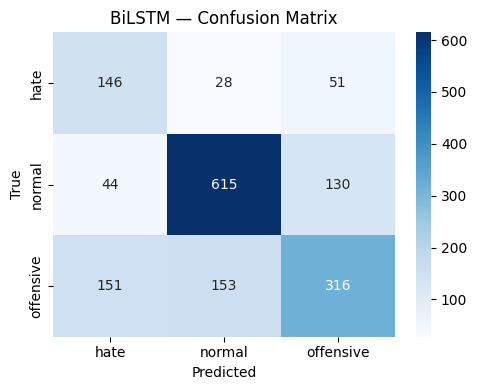

In [ ]:
tf.random.set_seed(SEED)

from tensorflow.keras.layers import SpatialDropout1D

lstm_model = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN, mask_zero=True),
    SpatialDropout1D(0.2),
    Bidirectional(LSTM(256, return_sequences=True, recurrent_dropout=0.1)),
    Dropout(0.2),
    Bidirectional(LSTM(128, recurrent_dropout=0.1)),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(NUM_CLASSES, activation='softmax')
], name='BiLSTM')

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

lstm_history = lstm_model.fit(
    X_train_dl, y_train_cat,
    validation_data=(X_val_dl, y_val_cat),
    epochs=20,
    batch_size=32,
    class_weight=cw_multi_dict,
    callbacks=get_callbacks(),
    verbose=1
)

plot_history(lstm_history, 'BiLSTM')
evaluate_dl_model('BiLSTM', lstm_model, X_test_dl, y_multi_test)

## 16. Model 7 — GRU

Model: "BiGRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
409/409 ━━━━━━━━━━━━━━━━━━━━ 636s 2s/step - accuracy: 0.5580 - loss: 0.9029 - val_accuracy: 0.6595 - val_loss: 0.7586 - learning_rate: 0.0010
Epoch 2/20
409/409 ━━━━━━━━━━━━━━━━━━━━ 615s 2s/step - accuracy: 0.7496 - loss: 0.5933 - val_accuracy: 0.6620 - val_loss: 0.8228 - learning_rate: 0.0010
Epoch 3/20
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8373 - loss: 0.4189
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
409/409 ━━━━━━━━━━━━━━━━━━━━ 606s 1s/step - accuracy: 0.8561 - loss: 0.3766 - val_accuracy: 0.6283 - val_loss: 1.1012 - learning_rate: 0.0010
Epoch 4/20
409/409 ━━━━━━━━━━━━━━━━━━━━ 613s 1s/step - accuracy: 0.9142 - loss: 0.2300 - val_accuracy: 0.6326 - val_loss: 1.2506 - learning_rate: 5.0000e-04
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


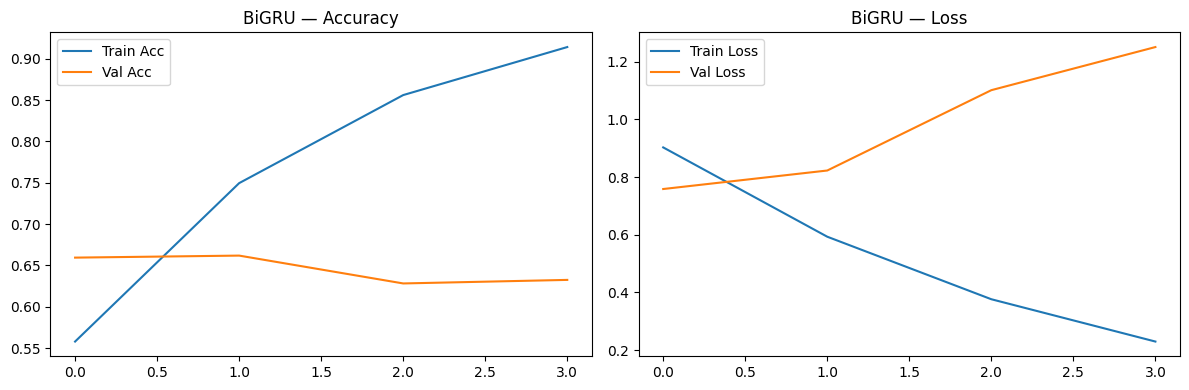


========== BiGRU ==========
  Accuracy  : 65.54%
  Precision : 67.57%
  Recall    : 65.54%
  F1-Score  : 64.48%

              precision    recall  f1-score   support

        hate       0.42      0.70      0.53       225
      normal       0.74      0.84      0.79       789
   offensive       0.69      0.40      0.51       620

    accuracy                           0.66      1634
   macro avg       0.62      0.65      0.61      1634
weighted avg       0.68      0.66      0.64      1634



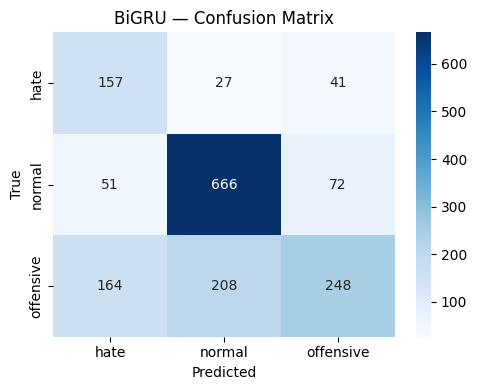

In [ ]:
tf.random.set_seed(SEED)

gru_model = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN, mask_zero=True),
    SpatialDropout1D(0.2),
    Bidirectional(GRU(256, return_sequences=True, recurrent_dropout=0.1)),
    Dropout(0.2),
    Bidirectional(GRU(128, recurrent_dropout=0.1)),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(NUM_CLASSES, activation='softmax')
], name='BiGRU')

gru_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

gru_model.summary()

gru_history = gru_model.fit(
    X_train_dl, y_train_cat,
    validation_data=(X_val_dl, y_val_cat),
    epochs=20,
    batch_size=32,
    class_weight=cw_multi_dict,
    callbacks=get_callbacks(),
    verbose=1
)

plot_history(gru_history, 'BiGRU')
evaluate_dl_model('BiGRU', gru_model, X_test_dl, y_multi_test)

## 17. Final Results Comparison

In [ ]:
results_df = pd.DataFrame(results_log).T
results_df.index.name = 'Model'
results_df = results_df.reset_index()

print('\n========== FULL RESULTS SUMMARY ==========')
print(results_df.to_string(index=False))


========== FULL RESULTS SUMMARY ==========
                            Model  Accuracy  Precision  Recall  F1-Score
               Binary Naive Bayes     78.58      78.58   78.58     78.57
          Multinomial Naive Bayes     64.75      66.62   64.75     65.41
     Logistic Regression (Binary)     80.54      80.58   80.54     80.54
Logistic Regression (Multi-class)     69.95      69.77   69.95     69.79
                              RNN     60.47      62.31   60.47     59.48
                           BiLSTM     65.91      67.33   65.91     66.04
                            BiGRU     65.54      67.57   65.54     64.48


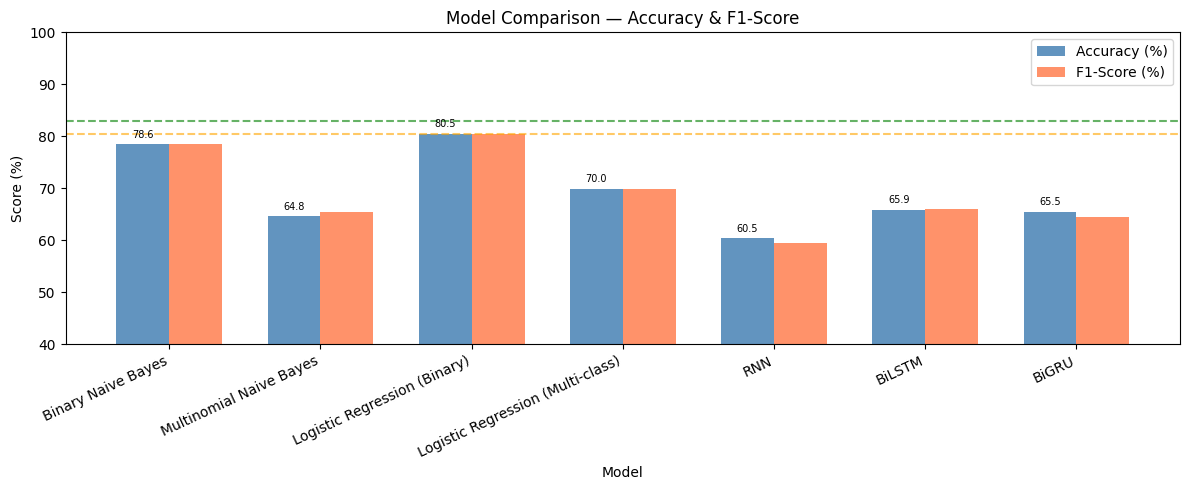

Chart saved as model_comparison.png


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

models = results_df['Model'].values
accuracies = results_df['Accuracy'].values
f1_scores  = results_df['F1-Score'].values

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy (%)',  color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, f1_scores,  width, label='F1-Score (%)',  color='coral',     alpha=0.85)

ax.set_xlabel('Model')
ax.set_ylabel('Score (%)')
ax.set_title('Model Comparison — Accuracy & F1-Score')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=25, ha='right')
ax.legend()
ax.set_ylim(40, 100)
ax.axhline(y=82.96, color='green',  linestyle='--', alpha=0.6, label='Paper LR baseline')
ax.axhline(y=80.39, color='orange', linestyle='--', alpha=0.6, label='Paper RNN baseline')

for bar in bars1:
    ax.annotate(f'{bar.get_height():.1f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points',
                ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as model_comparison.png')

## 18. Discussion

### Preprocessing Choices
- **Script filtering** (`\u0600-\u06FF`): Keeps only Urdu/Arabic script characters, automatically removing English and Roman Urdu words without needing an external language detection library. This is the single most important preprocessing step for Urdu NLP.
- **Normalization**: Normalizes Arabic character variants (e.g. `ك → ک`, `ى → ی`) to their Urdu-standard forms, significantly reducing vocabulary fragmentation.
- **SMOTE**: Applied to ML models to address the heavy class imbalance (`normal: 7891`, `offensive: 6199`, `hate: 2247`).
- **Class weights**: Used in DL models via `class_weight` argument in `.fit()` as an alternative to SMOTE.

### Model Architecture Choices
- **Bidirectional LSTM / GRU**: Using Bidirectional wrappers helps capture context from both directions in Urdu text, which reads right-to-left but where dependencies span both directions in the semantic sense.
- **Two stacked recurrent layers**: Provides deeper feature extraction.
- **Early stopping + ReduceLROnPlateau**: Prevents overfitting and helps converge to a better optimum.

### Challenges
1. **Class imbalance**: The `hate` class (~14%) is the hardest to detect; SMOTE and class weighting are critical.
2. **Urdu morphology**: Urdu is highly inflected; TF-IDF with unigrams+bigrams+trigrams partially captures this.
3. **Arabic-Urdu overlap**: Both share the same Unicode block; normalization ensures Arabic variants map to Urdu forms.
4. **Reproducibility**: DL training on GPU introduces minor non-determinism even with fixed seeds.

### Possible Improvements
- Pre-trained Urdu word embeddings (e.g., fastText Urdu vectors)
- Transformer-based models: XLM-RoBERTa or multilingual-BERT fine-tuned on Urdu
- Urdu stemming/lemmatization via Camel-Tools
- Focal Loss to further address class imbalance in DL models (as used in the paper)
- Ensemble of LR + GRU predictions